
# Notebook 09 — Modelo Informer: entrenamiento y optimizacion de hiperparametros

Este notebook implementa y entrena el modelo **Informer** (Zhou et al., 2021) para la prediccion de irradiancia solar (RS) a partir de los artefactos generados en el Notebook 04 (`data_norm.npy`, `marcas_temp.npy`, escaladores y `config_fe.pkl`).

**Articulacion con la Actividad 3.** Se evalua un mismo modelo bajo distintas variantes, en dos ejes:

- **Grupos de variables (ablacion):** V1 autorregresivo (RS + ciclos temporales), V2 con variables meteorologicas de NASA POWER y V3 completo (incluyendo los productos satelitales de irradiancia ALLSKY, CLRSKY y el indice de claridad KT). La comparacion cuantifica el aporte marginal de NASA POWER, nucleo de la justificacion metodologica del proyecto.
- **Horizonte de prediccion:** 1 h, 3 h y 6 h.

**Alcance de este notebook (05):** motor de entrenamiento, optimizacion de hiperparametros con evidencia empirica (tabla y figura) y seleccion de la configuracion definitiva. El entrenamiento final de todas las variantes y horizontes, las metricas de desempeno, las figuras de prediccion frente a observacion y la comparacion con la linea base de persistencia se desarrollan en el **Notebook 06**.

**Arquitectura de referencia:** se emplea la implementacion oficial del Informer (repositorio `zhouhaoyi/Informer2020`), construyendo alrededor de ella el motor de entrenamiento propio, articulado con la clase `InformerDataset` del Notebook 04.

---
## Cambios de la revision (septiembre de 2026)

**Embargo en las fronteras.** La funcion `build_loaders` usa ahora los indices con embargo que
guarda el cuaderno 04 revisado. Con ellos, ninguna ventana de validacion o de prueba comparte un
solo instante con ninguna ventana de entrenamiento. La celda de carga avisa si los artefactos
son antiguos y no traen embargo.

**Por que se rehace la busqueda de hiperparametros.** El conjunto cambio: tiene el embargo y el
indice de claridad corregido. Rehacer la busqueda cuesta unos noventa minutos y evita tener que
escribir en el documento que los hiperparametros se optimizaron sobre una version previa del
conjunto. Si la mejor configuracion resulta ser la misma de antes, eso mismo es un dato: la
seleccion es estable.

**Antes de ejecutar.** Requiere los cuadernos 02 y 04 revisados, en ese orden.
---

In [ ]:
# 1. Configuracion del entorno
!pip install torch numpy pandas matplotlib scikit-learn --quiet

import os, sys, gc, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = torch.cuda.is_available()   # precision mixta solo en GPU; si hubiera error de tipo, fijar en False

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.

# MODO de ejecucion:
#   'piloto'   -> stride alto y pocas epocas: valida el flujo completo en minutos
#   'completo' -> stride bajo y mas epocas: corrida definitiva para el documento
MODO = 'completo'

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('AMP     :', USE_AMP)
print('MODO    :', MODO)

PyTorch : 2.11.0+cu128
Device  : cuda
AMP     : True
MODO    : completo


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
archivo_de_datos('config_fe.pkl', pista='Lo genera el cuaderno 04.')


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados


'/content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos/arrays/config_fe.pkl'

### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# 3. Modelo de referencia: implementacion oficial del Informer
# Zhou et al. (2021), "Informer: Beyond Efficient Transformer for Long
# Sequence Time-Series Forecasting", AAAI. Repositorio: zhouhaoyi/Informer2020.
REPO_INFORMER = '/content/Informer2020'
if not os.path.exists(REPO_INFORMER):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/zhouhaoyi/Informer2020.git',
                    REPO_INFORMER], check=True)
if REPO_INFORMER not in sys.path:
    sys.path.append(REPO_INFORMER)

from models.model import Informer
print('Arquitectura Informer importada correctamente.')

Arquitectura Informer importada correctamente.


In [ ]:
# 4. Carga de artefactos del Notebook 04
data_norm   = np.load(os.path.join(RUTA_ARRAYS, 'data_norm.npy'))
marcas_temp = np.load(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'))
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'rb') as f:
    config = pickle.load(f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'rb') as f:
    scaler_rs = pickle.load(f)

VARS_ENTRADA  = list(config['vars_entrada'])
VAR_OBJETIVO  = config['var_objetivo']
IDX_OBJETIVO  = config['idx_objetivo']
SEQ_LEN       = config['seq_len']
LABEL_LEN     = config['label_len']
PRED_LENS     = config['pred_lens']
IDX_TRAIN_END = config['idx_train_end']
IDX_VAL_END   = config['idx_val_end']
N_TOTAL       = config['n_total']

# --- Indices con embargo — PARCHE DE LA REVISION -------------------------
# Los .get con valor por defecto permiten que el cuaderno siga funcionando con
# artefactos generados antes del parche, pero entonces avisa.
IDX_TRAIN_INI = config.get('idx_train_ini', 0)
IDX_TRAIN_FIN = config.get('idx_train_fin', IDX_TRAIN_END)
IDX_VAL_INI   = config.get('idx_val_ini',   IDX_TRAIN_END)
IDX_VAL_FIN   = config.get('idx_val_fin',   IDX_VAL_END)
IDX_TEST_INI  = config.get('idx_test_ini',  IDX_VAL_END)
IDX_TEST_FIN  = config.get('idx_test_fin',  N_TOTAL)
EMBARGO       = config.get('embargo', 0)

# Factor de desnormalizacion de RS (MinMax): W/m2 = norm * range + min
RS_MIN   = float(scaler_rs.data_min_[0])
RS_RANGE = float(scaler_rs.data_range_[0])

print('data_norm   :', data_norm.shape, data_norm.dtype)
print('marcas_temp :', marcas_temp.shape, marcas_temp.dtype)
print('Variables   :', len(VARS_ENTRADA), '| Objetivo:', VAR_OBJETIVO, '(idx', IDX_OBJETIVO, ')')
print('Horizontes  :', PRED_LENS)
print('RS_min      :', round(RS_MIN, 3), '| RS_range:', round(RS_RANGE, 3), 'W/m2')
print()
print(f'Embargo     : {EMBARGO} pasos por frontera '
      f'({EMBARGO*5/60:.0f} horas)')
print(f'Bloques     : train [{IDX_TRAIN_INI}, {IDX_TRAIN_FIN})  '
      f'val [{IDX_VAL_INI}, {IDX_VAL_FIN})  test [{IDX_TEST_INI}, {IDX_TEST_FIN})')
if EMBARGO == 0:
    print()
    print('AVISO: los artefactos no traen embargo. Reejecuta el cuaderno 04 revisado')
    print('antes de continuar, o el entrenamiento se hara sobre la particion antigua.')
else:
    assert EMBARGO > SEQ_LEN + max(PRED_LENS.values()), \
        'El embargo no supera la ventana de contexto mas el horizonte maximo.'
    print('Embargo verificado: supera la ventana de contexto mas el horizonte maximo.')

data_norm   : (1330560, 18) float32
marcas_temp : (1330560, 4) float32
Variables   : 18 | Objetivo: RS (idx 0 )
Horizontes  : {'1h': 12, '3h': 36, '6h': 72}
RS_min      : 0.0 | RS_range: 1524.0 W/m2

Embargo     : 576 pasos por frontera (48 horas)
Bloques     : train [0, 931391)  val [931967, 1130976)  test [1131552, 1330560)
Embargo verificado: supera la ventana de contexto mas el horizonte maximo.


## Variantes por grupos de variables

La comparacion entre variantes responde a una pregunta metodologica concreta: cuanto mejora la prediccion de RS al incorporar progresivamente informacion de NASA POWER. Se definen tres grupos anidados:

- **V1 — autorregresivo:** RS y sus ciclos temporales (hora, dia del anio, mes). Linea base endogena que solo usa la propia serie y la estacionalidad.
- **V2 — meteorologico NASA:** agrega variables meteorologicas y astronomicas de NASA POWER (T2M, RH2M, precipitacion, viento en componentes u/v, presion y angulo cenital solar), sin incluir aun la irradiancia satelital.
- **V3 — completo:** agrega los productos satelitales de irradiancia (ALLSKY, CLRSKY) y el indice de claridad (KT).

El caracter anidado de los grupos permite atribuir las diferencias de desempeno al bloque de variables incorporado en cada paso. RS se mantiene como primera columna en los tres grupos, de modo que su indice dentro del subconjunto es siempre 0.

In [ ]:
# 6. Definicion de las variantes por grupos de variables
GRUPOS_VARIABLES = {
    'V1_autorregresivo': [
        'RS', 'sin_hora', 'cos_hora',
        'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
    ],
    'V2_meteo_nasa': [
        'RS', 'sin_hora', 'cos_hora',
        'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
        'T2M', 'RH2M', 'PRECTOTCORR',
        'WS10M', 'WD10M_u', 'WD10M_v', 'PS', 'SZA',
    ],
    'V3_completo': list(VARS_ENTRADA),
}

def columnas_variante(nombre_variante):
    # Indices de columna en data_norm para la variante dada.
    # RS se ubica siempre en la posicion 0 del subconjunto.
    nombres = GRUPOS_VARIABLES[nombre_variante]
    return [VARS_ENTRADA.index(v) for v in nombres]

print('Variantes definidas:')
for k, v in GRUPOS_VARIABLES.items():
    print(f'  {k:<20} -> {len(v):>2} variables')

Variantes definidas:
  V1_autorregresivo    ->  7 variables
  V2_meteo_nasa        -> 15 variables
  V3_completo          -> 18 variables


## Construccion de DataLoaders y submuestreo temporal

A 5 minutos de resolucion, dos ventanas consecutivas comparten 287 de 288 pasos de contexto: son casi identicas. Entrenar sobre la totalidad de las ventanas es redundante y multiplica el costo sin aportar informacion proporcional. Por ello se aplica un submuestreo por `stride`: se toma una de cada `stride` ventanas, reduciendo el tiempo de entrenamiento de forma sustancial y conservando la cobertura de todo el periodo.

**Revision.** Los limites de cada bloque son ahora los indices con embargo del Notebook 04. Con ellos, la ventana de contexto de la primera muestra de validacion empieza despues del ultimo instante que el modelo vio durante el entrenamiento.

In [ ]:
# 8. Clase InformerDataset (identica a la del Notebook 04, autocontenida)
# Indexacion dinamica: cada muestra se extrae por slicing del array en RAM,
# sin materializar ventanas estaticas. Estructura de cada muestra:
#   enc_input (seq_len, n_vars) | enc_mark (seq_len, 4)
#   dec_input (label_len+pred_len, n_vars) con el objetivo enmascarado en el futuro
#   dec_mark  (label_len+pred_len, 4) | target (pred_len,)
class InformerDataset(Dataset):
    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data         = data
        self.marcas       = marcas
        self.seq_len      = seq_len
        self.label_len    = label_len
        self.pred_len     = pred_len
        self.idx_objetivo = idx_objetivo
        self._inicio = max(idx_inicio, seq_len)
        self._fin    = min(idx_fin, len(data) - pred_len)
        self._len    = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        t = self._inicio + i
        enc_input = self.data[t - self.seq_len : t, :]
        enc_mark  = self.marcas[t - self.seq_len : t, :]
        dec_start = t - self.label_len
        dec_end   = t + self.pred_len
        dec_input = self.data[dec_start : dec_end, :].copy()
        dec_mark  = self.marcas[dec_start : dec_end, :]
        dec_input[self.label_len:, self.idx_objetivo] = 0.0
        target = self.data[t : t + self.pred_len, self.idx_objetivo]
        return (
            torch.from_numpy(enc_input),
            torch.from_numpy(enc_mark),
            torch.from_numpy(dec_input),
            torch.from_numpy(dec_mark),
            torch.from_numpy(target),
        )

print('Clase InformerDataset definida.')

Clase InformerDataset definida.


In [ ]:
# 9. Construccion de DataLoaders por variante y horizonte
def build_loaders(nombre_variante, nombre_horizonte,
                  stride_train, stride_eval, batch_size, num_workers=2):
    # Nota: si en Colab aparecen errores de multiprocessing, usar num_workers=0.
    cols     = columnas_variante(nombre_variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])   # (N, k) float32
    pred_len = PRED_LENS[nombre_horizonte]
    enc_in   = data_sub.shape[1]

    # PARCHE DE LA REVISION: limites con embargo en las fronteras.
    splits = [
        ('train', IDX_TRAIN_INI, IDX_TRAIN_FIN, stride_train),
        ('val',   IDX_VAL_INI,   IDX_VAL_FIN,   stride_eval),
        ('test',  IDX_TEST_INI,  IDX_TEST_FIN,  stride_eval),
    ]
    loaders, tam = {}, {}
    for split, i_ini, i_fin, stride in splits:
        ds_full = InformerDataset(
            data_sub, marcas_temp, i_ini, i_fin,
            SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0
        )
        idx = list(range(0, len(ds_full), stride))
        ds  = Subset(ds_full, idx)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=num_workers, pin_memory=USE_AMP,
            drop_last=(split == 'train')
        )
        tam[split] = len(ds)
    return loaders, enc_in, pred_len, tam

print('Funcion build_loaders definida.')

Funcion build_loaders definida.


## Constructor del modelo

Se configura el Informer en modo multivariante a univariante (MS): el codificador y el decodificador reciben todas las variables de la variante (`enc_in = dec_in`) y la capa de proyeccion final entrega una unica salida, RS (`c_out = 1`). Se conservan los mecanismos caracteristicos del Informer: atencion ProbSparse (`attn='prob'`), destilacion del codificador (`distil=True`) y decodificacion generativa mediante el prefijo conocido `label_len` mas el horizonte enmascarado. El embebido temporal `timeF` proyecta linealmente las 4 marcas temporales al espacio del modelo.

In [ ]:
# 11. Constructor del modelo Informer (modo MS: multivariante -> univariante)
def build_informer(enc_in, pred_len, hp):
    model = Informer(
        enc_in=enc_in, dec_in=enc_in, c_out=1,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, out_len=pred_len,
        factor=hp['factor'], d_model=hp['d_model'], n_heads=hp['n_heads'],
        e_layers=hp['e_layers'], d_layers=hp['d_layers'], d_ff=hp['d_ff'],
        dropout=hp['dropout'], attn='prob', embed='timeF', freq='h',
        activation='gelu', output_attention=False, distil=True, mix=True,
        device=DEVICE
    ).to(DEVICE)
    return model

def contar_parametros(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Funcion build_informer definida.')

Funcion build_informer definida.


## Motor de entrenamiento

La estrategia de entrenamiento es comun a todas las variantes para garantizar comparaciones en igualdad de condiciones: perdida MSE en el espacio normalizado, optimizador Adam con regularizacion L2 leve, reduccion de la tasa de aprendizaje al estancarse la validacion, recorte de la norma del gradiente y parada temprana sobre la perdida de validacion. En GPU se activa precision mixta para acelerar el computo. Si en algun entorno la precision mixta produjera errores de tipo, basta con fijar `USE_AMP = False` en la primera celda.

In [ ]:
# 13. Motor de entrenamiento: evaluacion de perdida y ciclo de entrenamiento
def _mover(batch):
    enc, enc_m, dec, dec_m, tgt = batch
    return (enc.to(DEVICE), enc_m.to(DEVICE),
            dec.to(DEVICE), dec_m.to(DEVICE), tgt.to(DEVICE))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out  = model(enc, enc_m, dec, dec_m).squeeze(-1)   # (B, pred_len)
            loss = criterion(out, tgt)
        total += loss.item() * tgt.size(0)
        n     += tgt.size(0)
    return total / max(n, 1)

def train_model(model, loaders, max_epochs=15, lr=5e-4, weight_decay=1e-4,
                patience=4, clip=1.0, ruta_ckpt=None, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler(DEVICE_TYPE, enabled=USE_AMP)

    historia = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')
    sin_mejora = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        t0, suma, n = time.time(), 0.0, 0
        for batch in loaders['train']:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            optimizer.zero_grad(set_to_none=True)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out  = model(enc, enc_m, dec, dec_m).squeeze(-1)
                loss = criterion(out, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer)
            scaler.update()
            suma += loss.item() * tgt.size(0)
            n    += tgt.size(0)

        train_loss = suma / max(n, 1)
        val_loss   = evaluate_loss(model, loaders['val'], criterion)
        scheduler.step(val_loss)
        lr_actual  = optimizer.param_groups[0]['lr']

        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['lr'].append(lr_actual)

        if verbose:
            print(f'  Epoca {epoch:>2}/{max_epochs} | train {train_loss:.5e} | '
                  f'val {val_loss:.5e} | lr {lr_actual:.1e} | {time.time()-t0:.1f}s')

        if val_loss < best_val - 1e-7:
            best_val, sin_mejora = val_loss, 0
            if ruta_ckpt is not None:
                torch.save(model.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                if verbose:
                    print(f'  Parada temprana en epoca {epoch} (sin mejora en {patience} epocas).')
                break

    return best_val, historia

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


In [ ]:
# 14. Prueba de humo (smoke test)
# Verifica de extremo a extremo tensores, modelo y ciclo de entrenamiento
# con un modelo pequeno y muy pocas ventanas (debe correr en pocos minutos).
hp_prueba = dict(factor=5, d_model=128, n_heads=4, e_layers=2,
                 d_layers=1, d_ff=128, dropout=0.05)

loaders_t, enc_in_t, pred_len_t, tam_t = build_loaders(
    'V3_completo', '1h', stride_train=200, stride_eval=200, batch_size=32)
print('Tamanos (smoke):', tam_t, '| enc_in:', enc_in_t)

modelo_t = build_informer(enc_in_t, pred_len_t, hp_prueba)
print('Parametros entrenables:', f'{contar_parametros(modelo_t):,}')

best_v, hist_t = train_model(modelo_t, loaders_t, max_epochs=2, lr=5e-4,
                             patience=2, ruta_ckpt=None, verbose=True)
print('Smoke test OK. Mejor val:', f'{best_v:.5e}')

del modelo_t, loaders_t
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Tamanos (smoke): {'train': 4656, 'val': 996, 'test': 995} | enc_in: 18
Parametros entrenables: 430,593
  Epoca  1/2 | train 3.61746e-02 | val 1.27499e-02 | lr 5.0e-04 | 8.7s
  Epoca  2/2 | train 7.10323e-03 | val 1.14603e-02 | lr 5.0e-04 | 5.7s
Smoke test OK. Mejor val: 1.14603e-02


## Optimizacion de hiperparametros

La optimizacion se realiza mediante busqueda aleatoria sobre la variante mas informativa (V3) y el horizonte mas corto (1 h), por ser el de entrenamiento mas rapido. Cada configuracion se entrena unas pocas epocas con parada temprana y se evalua por su perdida de validacion. La mejor configuracion se fija y se reutiliza para entrenar todas las variantes y horizontes en el Notebook 06, manteniendo la comparacion en igualdad de condiciones.

**Cuanto tarda.** En la ejecucion anterior, las doce configuraciones tomaron unos 91 minutos en una GPU T4. La tabla `resultados/hpo_resultados.csv` y la figura de perdida de validacion constituyen la evidencia empirica de la optimizacion.

In [ ]:
# 16. Optimizacion de hiperparametros (busqueda aleatoria sobre V3, horizonte 1h)
ESPACIO_HP = {
    'd_model' : [128, 256, 512],
    'n_heads' : [4, 8],
    'e_layers': [2, 3],
    'd_layers': [1, 2],
    'd_ff'    : [128, 256, 512],
    'dropout' : [0.05, 0.10, 0.15],
    'factor'  : [3, 5],
    'lr'      : [1e-3, 5e-4, 1e-4],
}

if MODO == 'piloto':
    N_CONFIGS, HPO_STRIDE_TRAIN, HPO_STRIDE_EVAL, HPO_EPOCHS, BATCH = 4, 60, 60, 3, 64
else:
    N_CONFIGS, HPO_STRIDE_TRAIN, HPO_STRIDE_EVAL, HPO_EPOCHS, BATCH = 12, 18, 24, 6, 64

rng = np.random.default_rng(SEED)
def muestrear_hp():
    return {k: rng.choice(v).item() for k, v in ESPACIO_HP.items()}

loaders_hpo, enc_in_hpo, pred_len_hpo, tam_hpo = build_loaders(
    'V3_completo', '1h',
    stride_train=HPO_STRIDE_TRAIN, stride_eval=HPO_STRIDE_EVAL, batch_size=BATCH)
print('Ventanas HPO:', tam_hpo, '| enc_in:', enc_in_hpo)
print('=' * 70)

registros, vistas = [], set()
for i in range(N_CONFIGS):
    hp = muestrear_hp()
    while (tuple(hp.items()) in vistas) or (hp['d_model'] % hp['n_heads'] != 0):
        hp = muestrear_hp()
    vistas.add(tuple(hp.items()))

    lr = hp.pop('lr')
    print(f'[{i+1}/{N_CONFIGS}] d_model={hp["d_model"]} heads={hp["n_heads"]} '
          f'e={hp["e_layers"]} d={hp["d_layers"]} d_ff={hp["d_ff"]} '
          f'drop={hp["dropout"]} factor={hp["factor"]} lr={lr:.0e}')
    t0     = time.time()
    modelo = build_informer(enc_in_hpo, pred_len_hpo, hp)
    n_par  = contar_parametros(modelo)
    best_v, _ = train_model(modelo, loaders_hpo, max_epochs=HPO_EPOCHS,
                            lr=lr, patience=2, ruta_ckpt=None, verbose=False)
    dur = time.time() - t0
    registros.append({**hp, 'lr': lr, 'n_parametros': n_par,
                      'val_loss': best_v, 'segundos': round(dur, 1)})
    print(f'      -> val_loss={best_v:.5e} | params={n_par:,} | {dur:.1f}s')
    del modelo
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_hpo = pd.DataFrame(registros).sort_values('val_loss').reset_index(drop=True)
df_hpo.to_csv(os.path.join(RUTA_RES, 'hpo_resultados.csv'), index=False)
print('=' * 70)
print('Resultados de la busqueda (ordenados por val_loss):')
print(df_hpo.to_string(index=False))

Ventanas HPO: {'train': 51728, 'val': 8293, 'test': 8292} | enc_in: 18
[1/12] d_model=128 heads=8 e=3 d=1 d_ff=256 drop=0.15 factor=3 lr=1e-04
      -> val_loss=6.64857e-03 | params=711,297 | 275.1s
[2/12] d_model=128 heads=4 e=3 d=2 d_ff=512 drop=0.15 factor=5 lr=1e-04
      -> val_loss=6.63668e-03 | params=1,239,041 | 360.2s
[3/12] d_model=256 heads=4 e=3 d=1 d_ff=256 drop=0.1 factor=3 lr=1e-04
      -> val_loss=6.53860e-03 | params=2,273,537 | 322.3s
[4/12] d_model=512 heads=8 e=2 d=2 d_ff=256 drop=0.1 factor=3 lr=1e-03
      -> val_loss=6.31419e-03 | params=8,217,601 | 849.4s
[5/12] d_model=128 heads=8 e=3 d=1 d_ff=512 drop=0.15 factor=3 lr=5e-04
      -> val_loss=6.44326e-03 | params=974,465 | 282.0s
[6/12] d_model=128 heads=8 e=3 d=1 d_ff=128 drop=0.15 factor=3 lr=1e-04
      -> val_loss=6.73588e-03 | params=579,713 | 266.5s
[7/12] d_model=512 heads=8 e=3 d=1 d_ff=256 drop=0.1 factor=3 lr=1e-03
      -> val_loss=1.22696e-02 | params=7,953,921 | 370.6s
[8/12] d_model=256 heads=4 e

Mejor configuracion (val_loss = 6.31419e-03):
  d_model   : 512
  n_heads   : 8
  e_layers  : 2
  d_layers  : 2
  d_ff      : 256
  dropout   : 0.1
  factor    : 3
  lr        : 0.001

Distancia entre las dos mejores: 1.786 % de perdida de validacion.
Si es pequenia, la seleccion es estable frente a variaciones menores
del resto de hiperparametros, y conviene decirlo en el documento.
  Figura guardada: hpo_val_loss.png, .svg y .pdf


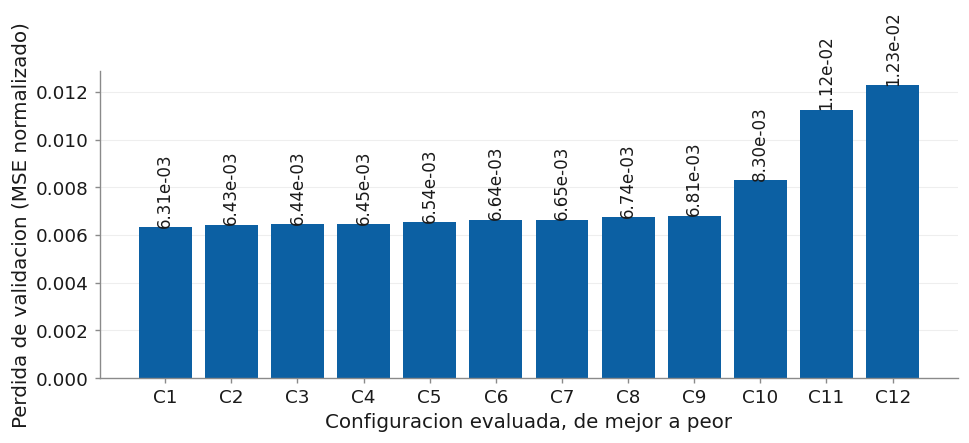


Config. guardada   : resultados/hp_best.pkl
Tabla guardada     : resultados/hpo_resultados.csv


In [ ]:
# 17. Seleccion y registro de la mejor configuracion
mejor = df_hpo.iloc[0].to_dict()
enteros = ['d_model', 'n_heads', 'e_layers', 'd_layers', 'd_ff', 'factor']
HP_BEST = {k: (int(mejor[k]) if k in enteros else float(mejor[k]))
           for k in ['d_model', 'n_heads', 'e_layers', 'd_layers', 'd_ff', 'dropout', 'factor', 'lr']}

with open(os.path.join(RUTA_RES, 'hp_best.pkl'), 'wb') as f:
    pickle.dump(HP_BEST, f)

print('Mejor configuracion (val_loss = %.5e):' % mejor['val_loss'])
for k, v in HP_BEST.items():
    print(f'  {k:<10}: {v}')

# Estabilidad de la seleccion: distancia entre las dos mejores configuraciones
if len(df_hpo) >= 2:
    v1, v2 = df_hpo['val_loss'].iloc[0], df_hpo['val_loss'].iloc[1]
    print()
    print(f'Distancia entre las dos mejores: {abs(v2-v1)/v1*100:.3f} % de perdida de validacion.')
    print('Si es pequenia, la seleccion es estable frente a variaciones menores')
    print('del resto de hiperparametros, y conviene decirlo en el documento.')

# --- Evidencia grafica — PARCHE DE LA REVISION ---------------------------
# Sin titulo interno: el titulo va en el caption de LaTeX. Salida vectorial en
# PDF, letra legible y una sola familia de color.
fig, ax = plt.subplots(figsize=(9, 4.2))
etiquetas = [f'C{i+1}' for i in range(len(df_hpo))]
ax.bar(etiquetas, df_hpo['val_loss'].values, color=C_AZUL)
ax.set_ylabel('Perdida de validacion (MSE normalizado)', fontsize=13)
ax.set_xlabel('Configuracion evaluada, de mejor a peor', fontsize=13)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
for i, v in enumerate(df_hpo['val_loss'].values):
    ax.text(i, v, f'{v:.2e}', ha='center', va='bottom', fontsize=11, rotation=90)
plt.tight_layout()
guardar_figura(fig, 'hpo_val_loss')
plt.show()

print()
print('Config. guardada   : resultados/hp_best.pkl')
print('Tabla guardada     : resultados/hpo_resultados.csv')

## Resumen y siguiente paso

Al ejecutar este cuaderno se obtienen tres artefactos para el documento y para el Notebook 06:

- `resultados/hpo_resultados.csv` — tabla de configuraciones evaluadas y su perdida de validacion.
- `figuras_PDF/hpo_val_loss.pdf` — evidencia grafica de la optimizacion.
- `resultados/hp_best.pkl` — configuracion de hiperparametros seleccionada.

**Antes de pasar al Notebook 06**, manda a Claude la tabla `df_hpo` completa y la configuracion
seleccionada. Con eso se actualiza la Tabla de hiperparametros del documento y el texto de la
Etapa 5.

**Recomendacion de ejecucion:** correr primero con `MODO = 'piloto'` para validar el flujo
completo en pocos minutos; una vez confirmado, cambiar a `MODO = 'completo'` para la corrida
definitiva.